## Import

In [1]:
# Standard python imports.
import gdstk
import matplotlib.pylab as plt
import numpy as np
import time

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins import waveguide
from scipy import optimize
import matplotlib.pyplot as plt

pi=np.pi

22:38:33 UTC WARNING: Using canonical configuration directory at                
             '/home/tidy3d/.config/tidy3d'. Found legacy directory at           
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

In [2]:
def slab_TE_beta(k,twg,n_core,n_padding,m):
    a = twg/2; # half waveguide thickness
    v = k*a*np.sqrt(n_core**2-n_padding**2); # normalized frequency
    m_max = np.floor(v*2/pi); # maximum mode number at this wl, starts with 0
    if m>m_max: # mode m does not exist
        beta = NaN;
    else:
        dispersion_eq=lambda b: v*np.sqrt(1-b) - m*pi/2 - np.atan(np.sqrt(b/(1-b)));
        sol=optimize.root_scalar(dispersion_eq,x0=0.05,x1=0.95,method='secant')
        b=sol.root
        u = v*np.sqrt(1-b);
        w = v*np.sqrt(b);
        beta = np.sqrt(b*(n_core**2-n_padding**2)+n_padding**2)*k; # propagation constant
    return beta

def slab_TM_beta(k,twg,n_core,n_padding,m):
    a = twg/2; # half waveguide thickness
    v = k*a*np.sqrt(n_core**2-n_padding**2); # normalized frequency
    m_max = np.floor(v*2/pi); # maximum mode number at this wl, starts with 0
    if m>m_max: # mode m does not exist
        beta = NaN;
    else:
        dispersion_eq=lambda b: v*np.sqrt(1-b) - m*pi/2 - np.atan(n_core**2/n_padding**2*np.sqrt(b/(1-b)));
        sol=optimize.root_scalar(dispersion_eq,x0=0.05,x1=0.95,method='secant')
        b=sol.root
        u = v*np.sqrt(1-b)
        w = v*np.sqrt(b)
        beta = np.sqrt(b*(n_core**2-n_padding**2)+n_padding**2)*k # propagation constant
    return beta

def slab_TE_Eperp(z,k,twg,n_core,n_padding,m):
    a = twg/2; # half waveguide thickness
    v = k*a*np.sqrt(n_core**2-n_padding**2); # normalized frequency
    m_max = np.floor(v*2/pi); # maximum mode number at this wl, starts with 0
    if m>m_max: # mode m does not exist
        beta = NaN;
    else:
        dispersion_eq=lambda b: v*np.sqrt(1-b) - m*pi/2 - np.atan(np.sqrt(b/(1-b)));
        sol=optimize.root_scalar(dispersion_eq,x0=0.05,x1=0.95,method='secant')
        b=sol.root
        u = v*np.sqrt(1-b);
        w = v*np.sqrt(b);
        beta = np.sqrt(b*(n_core**2-n_padding**2)+n_padding**2)*k; # propagation constant
    kappa=u/a
    xi=w/a
    phi=m*np.pi/2
    
    if z>twg/2:
        Eperp=np.cos(kappa*twg/2-phi)*np.exp(-xi*(z-twg/2))
    elif (-twg/2<=z) and (z<=twg/2):
        Eperp=np.cos(kappa*z-phi)
    else:
        Eperp=np.cos(kappa*twg/2+phi)*np.exp(xi*(z+twg/2))
    return Eperp

def slab_TE_Hperp(z,k,twg,n_core,n_padding,m):
    a = twg/2; # half waveguide thickness
    v = k*a*np.sqrt(n_core**2-n_padding**2); # normalized frequency
    m_max = np.floor(v*2/pi); # maximum mode number at this wl, starts with 0
    if m>m_max: # mode m does not exist
        beta = NaN;
    else:
        dispersion_eq=lambda b: v*np.sqrt(1-b) - m*pi/2 - np.atan(np.sqrt(b/(1-b)));
        sol=optimize.root_scalar(dispersion_eq,x0=0.05,x1=0.95,method='secant')
        b=sol.root
        u = v*np.sqrt(1-b);
        w = v*np.sqrt(b);
        beta = np.sqrt(b*(n_core**2-n_padding**2)+n_padding**2)*k; # propagation constant
    kappa=u/a
    xi=w/a
    phi=m*np.pi/2
    if z>twg/2:
        Hperp=beta/k*np.cos(kappa*twg/2-phi)*np.exp(-xi*(z-twg/2))
    elif (-twg/2<=z) and (z<=twg/2):
        Hperp=beta/k*np.cos(kappa*z-phi)
    else:
        Hperp=beta/k*np.cos(kappa*twg/2+phi)*np.exp(xi*(z+twg/2))
    return Hperp

In [3]:
def slab_TE_params(k,twg,n_core,n_padding,m):
    a = twg/2; # half waveguide thickness
    v = k*a*np.sqrt(n_core**2-n_padding**2); # normalized frequency
    m_max = np.floor(v*2/pi); # maximum mode number at this wl, starts with 0
    if m>m_max: # mode m does not exist
        beta = NaN
        kappa=NaN
        xi=NaN
        phi=NaN
    else:
        dispersion_eq=lambda b: v*np.sqrt(1-b) - m*pi/2 - np.atan(np.sqrt(b/(1-b)));
        sol=optimize.root_scalar(dispersion_eq,x0=0.05,x1=0.95,method='secant')
        b=sol.root
        u = v*np.sqrt(1-b);
        w = v*np.sqrt(b);
        beta = np.sqrt(b*(n_core**2-n_padding**2)+n_padding**2)*k; # propagation constant
        kappa=u/a
        xi=w/a
        phi=m*np.pi/2
    return beta,kappa,xi,phi

def slab_TE_Eperp_fast(z,k,twg,kappa,xi,phi):    
    if z>twg/2:
        Eperp=np.cos(kappa*twg/2-phi)*np.exp(-xi*(z-twg/2))
    elif (-twg/2<=z) and (z<=twg/2):
        Eperp=np.cos(kappa*z-phi)
    else:
        Eperp=np.cos(kappa*twg/2+phi)*np.exp(xi*(z+twg/2))
    return Eperp

def slab_TE_Hperp_fast(z,k,twg,kappa,xi,phi):
    if z>twg/2:
        Hperp=beta/k*np.cos(kappa*twg/2-phi)*np.exp(-xi*(z-twg/2))
    elif (-twg/2<=z) and (z<=twg/2):
        Hperp=beta/k*np.cos(kappa*z-phi)
    else:
        Hperp=beta/k*np.cos(kappa*twg/2+phi)*np.exp(xi*(z+twg/2))
    return Hperp

def slab_TE_Hpar_fast(z,k,twg,kappa,xi,phi):
    if z>twg/2:
        Hpar=1j/k*(-xi)*np.exp(-xi*(z-twg/2))*np.cos(kappa*twg/2-phi)
    elif (-twg/2<=z) and (z<=twg/2):
        Hpar=1j/k*kappa*np.sin(kappa*z-phi)
    else:
        Hpar=1j/k*xi*np.exp(xi*(z+twg/2))*np.cos(kappa*twg/2+phi)
    return Hpar

## System Parameters

In [4]:
wl=1.55
#wl=0.8
fomega=td.C_0/wl
omega=2*np.pi/wl   ######   Notice that omega and fomega have different units!!!
k=omega

#run_time = 1e-13
#run_time = 4e-13
#run_time = 8e-13
run_time = 12e-13
wls_source=np.linspace(wl-5e-2,wl+5e-2,101)
fsource=td.C_0/wls_source
fsourcewidth=0.5*(np.max(fsource)-np.min(fsource))

#ncore = 3.4
ncore = 3.0
#ncore = 2.0
core = td.Medium(permittivity=ncore**2)
nair=1
air=td.Medium(permittivity=nair**2)

twg=0.22

In [5]:
Lx=5*wl
deltak=2*pi/Lx
print( deltak )
NA=0.21
print( NA*omega )

0.8107335880231724
0.8512702674243311


In [6]:
#pointsperwl=10
pointsperwl=20
#pointsperwl=25
#pointsperwl=30
#pointsperwl=40
#pointsperwl=60

minfeature=wl/pointsperwl
#design_pixel_size=minfeature/2
design_pixel_size=minfeature
#Lx=wl
#Ly=wl
#Lx=2*wl
#Ly=2*wl
#Lx=3*wl
#Ly=3*wl
#Lx=5*wl
#Ly=5*wl
#Lx=6*wl
#Ly=6*wl
#Lx=7*wl
#Ly=7*wl
#Lx=8*wl
#Ly=8*wl
#Lx=10*wl
#Ly=10*wl
#Lx=15*wl
#Ly=15*wl
Lx=20*wl
Ly=20*wl
#Lx=25*wl
#Ly=25*wl
#etchdepth=7E-2
#etchdepth=11E-2
#etchdepth=22E-2
etchdepth=7E-2
#etchdepth=twg/2

#simsizeextra=2*(2*wl)
#simsizeextra=2*(1.5*wl)
#simsizeextra=2*wl
#simsizeextra=wl
gc_to_src=0.5*wl
src_to_pml=0.5*wl
#gc_to_src=0.25*wl
#src_to_pml=0.25*wl
simsizex=Lx+2*(gc_to_src+src_to_pml)
simsizey=simsizex
#simsizex=5*wl
#simsizez=4*wl
#simsizez=1.5*wl
simsizez=2*wl

k=omega
beta=slab_TE_beta(k,twg,ncore,1.0,0)
beta,kappa,xi,phi=slab_TE_params(k,twg,ncore,1.0,0)
#beta=k

In [7]:
designx=np.arange(-Lx/2,Lx/2,design_pixel_size)
designy=np.arange(-Ly/2,Ly/2,design_pixel_size)
designz=np.arange(twg/2-etchdepth,twg/2,design_pixel_size)
chimax=ncore**2-1
designX,designY=np.meshgrid(designx,designy)

## Simulation creation functions

In [8]:
beta=slab_TE_beta(k,twg,ncore,1.0,0)
beta,kappa,xi,phi=slab_TE_params(k,twg,ncore,1.0,0)
zwg=np.linspace(-twg/2-2*wl,twg/2+2*wl,round(1E3))
dzwg=zwg[1]-zwg[0]
Eywg=np.zeros(len(zwg))
Hzwg=np.zeros(len(zwg))
for i2 in range(len(Eywg)):
    Eywg[i2]=slab_TE_Eperp(zwg[i2],k,twg,ncore,1.0,0)
    Hzwg[i2]=slab_TE_Hperp(zwg[i2],k,twg,ncore,1.0,0)
wgpower000=0.5*np.abs(np.sum(Eywg*np.conj(Hzwg))*dzwg)
def slab_TE_Eperp_norm(z):
    return slab_TE_Eperp_fast(z,k,twg,kappa,xi,phi)/np.sqrt(wgpower000)
def slab_TE_Hperp_norm(z):
    return slab_TE_Hperp_fast(z,k,twg,kappa,xi,phi)/np.sqrt(wgpower000)
def slab_TE_Hpar_norm(z):
    return slab_TE_Hpar_fast(z,k,twg,kappa,xi,phi)/np.sqrt(wgpower000)

Eywgnorm=np.zeros(len(zwg))
Hzwgnorm=np.zeros(len(zwg))
for i2 in range(len(Eywg)):
    Eywgnorm[i2]=slab_TE_Eperp_norm(zwg[i2])
    Hzwgnorm[i2]=slab_TE_Hperp_norm(zwg[i2])
newwgpower=0.5*np.abs(np.sum(Eywgnorm*np.conj(Hzwgnorm))*dzwg)
print(newwgpower)

1.0000000000000002


### Unpatterned simulation

In [9]:
def makesimnopattern(theta)->td.Simulation:
#------------------------        Monitors           -----------------------
    
    fieldmonitorall=td.FieldMonitor(
        size=(td.inf,td.inf,td.inf),
        center=(0,0,0),
        name='fieldmonitorall',
        freqs=fomega,
        interval_space=[2,2,1],
    )
    
    gcfieldmonitorleft=td.FieldMonitor(
        size=(0,Ly,td.inf),
        center=(-Lx/2,0,0),
        name='gcfieldmonitorleft',
        freqs=fomega,
    )
    gcfieldmonitorright=td.FieldMonitor(
        size=(0,Ly,td.inf),
        center=(Lx/2,0,0),
        name='gcfieldmonitorright',
        freqs=fomega,
    )
    gcfieldmonitortop=td.FieldMonitor(
        size=(Lx,0,td.inf),
        center=(0,Ly/2,0),
        name='gcfieldmonitortop',
        freqs=fomega,
    )
    gcfieldmonitorbot=td.FieldMonitor(
        size=(Lx,0,td.inf),
        center=(0,-Ly/2,0),
        name='gcfieldmonitorbot',
        freqs=fomega,
    )
    gcfluxmonitorleft=td.FieldMonitor(
        size=(0,Ly,td.inf),
        center=(-Lx/2,0,0),
        name='gcfluxmonitorleft',
        freqs=fomega,
    )
    gcfluxmonitorright=td.FieldMonitor(
        size=(0,Ly,td.inf),
        center=(Lx/2,0,0),
        name='gcfluxmonitorright',
        freqs=fomega,
    )
    gcfluxmonitortop=td.FieldMonitor(
        size=(Lx,0,td.inf),
        center=(0,Ly/2,0),
        name='gcfluxmonitortop',
        freqs=fomega,
    )
    gcfluxmonitorbot=td.FieldMonitor(
        size=(Lx,0,td.inf),
        center=(0,-Ly/2,0),
        name='gcfluxmonitorbot',
        freqs=fomega,
    )

#------------------------        Source           -----------------------
    srcdist=src_to_pml
    srcpos1=-simsizex/2+srcdist
    srcpos2=-srcpos1
    #Nsrc1=50
    Nsrc1=round(Lx/wl*20)
    #Nsrcz=50
    Nsrcz=round(simsizez/wl*20)
    zsrc=np.linspace(-simsizez/2,simsizez/2,Nsrcz)
    othersrc=np.linspace(-simsizex/2+srcdist,simsizex/2-srcdist,Nsrc1)
#------------------------        left           -----------------------
    xsrc=np.array([srcpos1])
    ysrc=othersrc
    jEysrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jEzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jHzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    phase=np.exp(-1j*beta*np.sin(theta)*ysrc)*np.exp(1j*beta*np.cos(theta)*xsrc)
    for i2 in range(Nsrcz):
        jEysrc[0,:,i2,0]=-slab_TE_Hperp_norm(zsrc[i2])*phase
        jEzsrc[0,:,i2,0]=-slab_TE_Hpar_norm(zsrc[i2])*np.sin(theta)*phase
        jHzsrc[0,:,i2,0]=-slab_TE_Eperp_norm(zsrc[i2])*np.cos(theta)*phase
    jdata = td.FieldDataset(Ey=td.ScalarFieldDataArray(jEysrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Ez=td.ScalarFieldDataArray(jEzsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Hz=td.ScalarFieldDataArray(jHzsrc,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),          )
    source_left = td.CustomCurrentSource(
        source_time=td.GaussianPulse(freq0=fomega,fwidth=fsourcewidth),
        center=(np.mean(xsrc),np.mean(ysrc),np.mean(zsrc)),
        size=(xsrc[-1]-xsrc[0],ysrc[-1]-ysrc[0],zsrc[-1]-zsrc[0]),
        current_dataset=jdata,
    )
#------------------------        right           -----------------------
    xsrc=np.array([srcpos2])
    ysrc=othersrc
    jEysrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jEzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jHzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    phase=np.exp(-1j*beta*np.sin(theta)*ysrc)*np.exp(1j*beta*np.cos(theta)*xsrc)
    for i2 in range(Nsrcz):
        jEysrc[0,:,i2,0]=slab_TE_Hperp_norm(zsrc[i2])*phase
        jEzsrc[0,:,i2,0]=slab_TE_Hpar_norm(zsrc[i2])*np.sin(theta)*phase
        jHzsrc[0,:,i2,0]=slab_TE_Eperp_norm(zsrc[i2])*np.cos(theta)*phase
    jdata = td.FieldDataset(Ey=td.ScalarFieldDataArray(jEysrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Ez=td.ScalarFieldDataArray(jEzsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Hz=td.ScalarFieldDataArray(jHzsrc,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),          )
    source_right = td.CustomCurrentSource(
        source_time=td.GaussianPulse(freq0=fomega,fwidth=fsourcewidth),
        center=(np.mean(xsrc),np.mean(ysrc),np.mean(zsrc)),
        size=(xsrc[-1]-xsrc[0],ysrc[-1]-ysrc[0],zsrc[-1]-zsrc[0]),
        current_dataset=jdata,
    )
#------------------------        bot           -----------------------
    ysrc=np.array([srcpos1])
    xsrc=othersrc
    jExsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jEzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jHzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    phase=np.exp(-1j*beta*np.sin(theta)*ysrc)*np.exp(1j*beta*np.cos(theta)*xsrc)
    for i2 in range(Nsrcz):
        jExsrc[:,0,i2,0]=slab_TE_Hperp_norm(zsrc[i2])*phase
        jEzsrc[:,0,i2,0]=-slab_TE_Hpar_norm(zsrc[i2])*np.cos(theta)*phase
        jHzsrc[:,0,i2,0]=slab_TE_Eperp_norm(zsrc[i2])*np.sin(theta)*phase
    jdata = td.FieldDataset(Ex=td.ScalarFieldDataArray(jExsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Ez=td.ScalarFieldDataArray(jEzsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Hz=td.ScalarFieldDataArray(jHzsrc,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),          )
    source_bot = td.CustomCurrentSource(
        source_time=td.GaussianPulse(freq0=fomega,fwidth=fsourcewidth),
        center=(np.mean(xsrc),np.mean(ysrc),np.mean(zsrc)),
        size=(xsrc[-1]-xsrc[0],ysrc[-1]-ysrc[0],zsrc[-1]-zsrc[0]),
        current_dataset=jdata,
    )
#------------------------        top           -----------------------
    ysrc=np.array([srcpos2])
    xsrc=othersrc
    jExsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jEzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    jHzsrc=np.zeros([len(xsrc),len(ysrc),len(zsrc),1])*(1+1j)
    phase=np.exp(-1j*beta*np.sin(theta)*ysrc)*np.exp(1j*beta*np.cos(theta)*xsrc)
    for i2 in range(Nsrcz):
        jExsrc[:,0,i2,0]=-slab_TE_Hperp_norm(zsrc[i2])*phase
        jEzsrc[:,0,i2,0]=slab_TE_Hpar_norm(zsrc[i2])*np.cos(theta)*phase
        jHzsrc[:,0,i2,0]=-slab_TE_Eperp_norm(zsrc[i2])*np.sin(theta)*phase
    jdata = td.FieldDataset(Ex=td.ScalarFieldDataArray(jExsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Ez=td.ScalarFieldDataArray(jEzsrc/td.ETA_0,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),
                            Hz=td.ScalarFieldDataArray(jHzsrc,coords={"x":xsrc,"y":ysrc,"z":zsrc,"f":[fomega],},),          )
    source_top = td.CustomCurrentSource(
        source_time=td.GaussianPulse(freq0=fomega,fwidth=fsourcewidth),
        center=(np.mean(xsrc),np.mean(ysrc),np.mean(zsrc)),
        size=(xsrc[-1]-xsrc[0],ysrc[-1]-ysrc[0],zsrc[-1]-zsrc[0]),
        current_dataset=jdata,
    )
    
#------------------------        Rest of the unpatterned simulation           -----------------------
    sim_box = td.Box.from_bounds(
        rmin=(-simsizex/2,-simsizey/2,-simsizez/2),
        rmax=(simsizex/2,simsizey/2,simsizez/2),
    )
    slab_waveguide = td.Structure(
            geometry=td.Box.from_bounds(rmin=(-1e3,-1e3,-twg/2), rmax=(1e3,1e3,twg/2)),
            medium=core,
        )
    #print("minstep per wl=",pointsperwl)
    sim_no_pattern = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=pointsperwl, wavelength=wl
        ),
        structures=[
            slab_waveguide
        ],
        sources=[source_left,
                 source_right,
                 source_top,
                 source_bot,
                ],
        monitors=[#fieldmonitorall,
                  gcfieldmonitorleft,gcfieldmonitorright,
                  gcfieldmonitortop,gcfieldmonitorbot,
                  gcfluxmonitorleft,gcfluxmonitorright,
                  gcfluxmonitortop,gcfluxmonitorbot,
                 ],
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
        symmetry=(0, 0, 0),
    )
    return sim_no_pattern

#### Test making unpatterned simulation

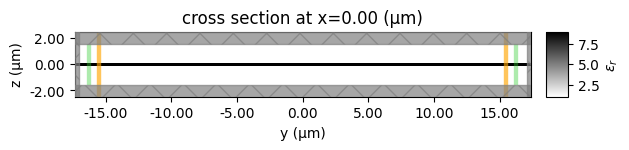

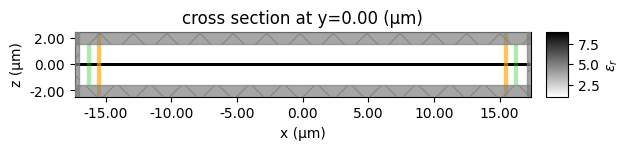

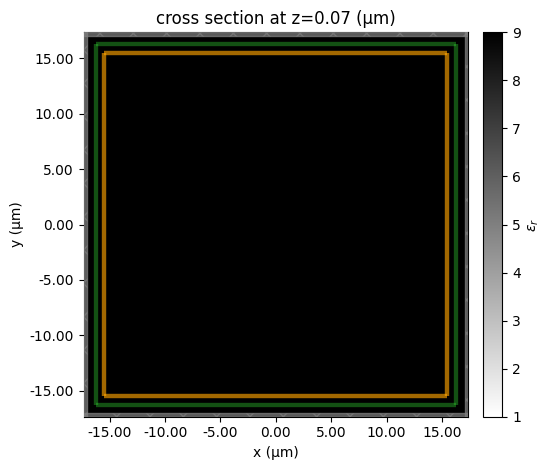

22:38:53 UTC Created task 'average_job' with resource_id                        
             'fdve-caa95745-8c63-4904-a398-ce2da5514bd6' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=464969;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=97662;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\taskId]8;;\]8;id=464969;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\=]8;;\]8;id=574038;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\fdve]8;;\]8;id=464969;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\-caa95745-8c6]8;;\
             ]8;id=464969;https://tidy3d.simulation.cloud/workbench?taskId=fdve-caa95745-8c63-4904-a398-ce2da5514bd6\3-4904-a398-ce2da5514bd6']8;;\.

             Task folder: ]8;id=854454;https://tidy3d.simulation.cloud/folders/folder-0e33148f-b29a-4849-904e-5b85ca531f95\'default']8;;\.

Output()

22:38:54 UTC Estimated FlexCredit cost: 1.030. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

22:38:55 UTC Estimated FlexCredit cost: 1.030. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

The estimated maximum cost is 1.030 Flex Credits.


In [10]:
#theta=0
theta=0.3*pi
#theta=0.5*pi
sim=makesimnopattern(theta)

sim.plot_eps(x=0)
plt.show()
sim.plot_eps(y=0)
plt.show()
sim.plot_eps(z=twg/2-etchdepth/2)
plt.show()
job = web.Job(simulation=sim, task_name="average_job", verbose=True)
estimated_cost = web.estimate_cost(job.task_id)
print(f'The estimated maximum cost is {estimated_cost:.3f} Flex Credits.')

### Patterned Simulation

In [11]:
def makesim(eps,theta):
    sim_no_pattern=makesimnopattern(theta)

#------------------      New sources      -------------------------
    monitordist=0.5*wl
    #monitordist=0.3*wl
    fieldmonitorup=td.FieldMonitor(
        size=(td.inf,td.inf,0),
        center=(0,0,twg/2+monitordist),
        name='fieldmonitorup',
        freqs=fomega,
    )
    fieldmonitordown=td.FieldMonitor(
        size=(td.inf,td.inf,0),
        center=(0,0,-twg/2-monitordist),
        name='fieldmonitordown',
        freqs=fomega,
    )
    fluxmonitorup=td.FluxMonitor(
        size=(td.inf,td.inf,0),
        center=(0,0,twg/2+monitordist),
        freqs=fomega,
        name='fluxmonitorup'
    )
    fluxmonitordown=td.FluxMonitor(
        size=(td.inf,td.inf,0),
        center=(0,0,-twg/2-monitordist),
        freqs=fomega,
        name='fluxmonitordown',
    )
    
#------------------      Rest      -------------------------
    design_region=td.Box(
    size=(Lx,Ly,etchdepth),
    center=(0,0,twg/2-etchdepth/2),
    )

    permittivity=td.SpatialDataArray(eps,coords=dict(x=designx,y=designy,z=designz))
    custom_medium=td.CustomMedium(permittivity=permittivity)
    pattern=td.Structure(geometry=design_region.geometry,medium=custom_medium)
    
    sim_with_pattern=sim_no_pattern.updated_copy(
    structures=list(sim_no_pattern.structures) + [pattern],
    monitors=list(sim_no_pattern.monitors) + [fieldmonitorup,fieldmonitordown,
                                            fluxmonitorup,fluxmonitordown],
    )
    return sim_with_pattern

#### Test making patterned simulation

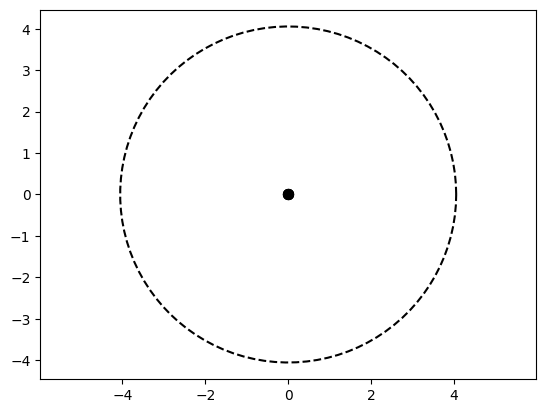

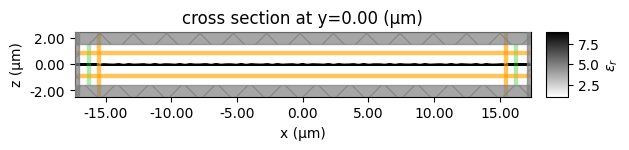

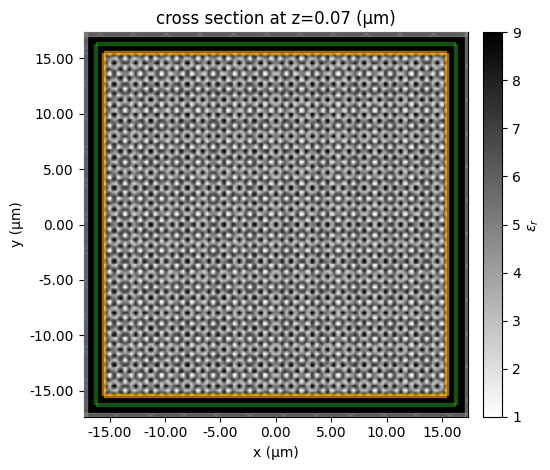

In [12]:
thetasq=np.array([0,pi/4,3*pi/4,pi/2])
#thetasq=np.array([0,pi/3,2*pi/3])
kxtargs=np.zeros([1,len(thetasq)])*omega*np.cos(thetasq)
kytargs=-np.zeros([1,len(thetasq)])*omega*np.sin(thetasq)
#kxtargs=np.array([0.6,0,-0.3])*omega
#kytargs=np.array([0,-0.4,0.4])*omega

plt.scatter(kxtargs,kytargs,s=50,color='black')
tt=np.linspace(0,2*pi,100)
plt.plot( omega*np.cos(tt),omega*np.sin(tt) ,linestyle='--',color='black')
plt.axis('equal')
plt.show()

#theta=0
deltatheta=2*pi/(beta*Lx)
theta=5*deltatheta
#theta=pi/4

Nfournow=4
#print('Started Nfour num '+str(i3)+'; Nfournow='+str(Nfournow))
qx=beta*np.cos(thetasq[0:Nfournow])-kxtargs[0:Nfournow]
qx=qx.reshape(1,1,-1)
qy=-beta*np.sin(thetasq[0:Nfournow])-kytargs[0:Nfournow]
qy=qy.reshape(1,1,-1)

nmin=1.0
chimin=nmin**2-1
eps0=1+chimin+(chimax-chimin)*(Nfournow+ np.sum(np.cos(qx*designX.reshape(designX.shape[0],designX.shape[1],1)+
                qy*designY.reshape(designY.shape[0],designY.shape[1],1)),axis=2) )/(2*Nfournow)
eps=np.zeros([len(designx),len(designy),len(designz)])
for i2 in range(len(designz)):
    eps[:,:,i2]=eps0.T

#kin=np.array([omega*np.sin(theta),omega*np.sin(theta)*np.sin(phiin)])
sim_with_pattern=makesim(eps,theta)
"""
volume = td.Box(center=(0,0,twg/2-etchdepth/2),size=(Lx+1E-6,Ly+1E-6,etchdepth+1E-2))
epssim=sim_with_pattern.epsilon(box=volume,coord_key="centers").to_numpy()
xepssim=sim_with_pattern.epsilon(box=volume,coord_key="centers")["x"].to_numpy()
yepssim=sim_with_pattern.epsilon(box=volume,coord_key="centers")["y"].to_numpy()
zepssim=sim_with_pattern.epsilon(box=volume,coord_key="centers")["z"].to_numpy()
plt.imshow(np.real(np.flip(epssim[:,:,0],axis=0)).T,
           extent=[-volume.size[0]/2,volume.size[0]/2,-volume.size[1]/2,volume.size[1]/2],
           cmap='RdBu',vmin=1,vmax=ncore**2)
plt.colorbar()
plt.show()
"""
#plt.plot(epssim[:,50])
#plt.show()

#sim_with_pattern.plot(y=0.0)
#plt.show()
#sim_with_pattern.plot(z=twg/2-etchdepth/2)
#plt.show()
sim_with_pattern.plot_eps(y=0)
plt.show()
sim_with_pattern.plot_eps(z=twg/2-etchdepth/2)
plt.show()
#job = web.Job(simulation=sim_with_pattern, task_name="average_job", verbose=True)
#estimated_cost = web.estimate_cost(job.task_id)
#print(f'The estimated maximum cost is {estimated_cost:.3f} Flex Credits.')

## Run

In [13]:
def runsim(sim):
    #import time
    #tic = time.perf_counter()
    simdata=web.run(simulation=sim,
                    task_name="average_job",
                    verbose=False,
                    path="3d_modesource_test_data/data.hdf5")
    #toc = time.perf_counter()
    #print(f"Single mode simulation took {toc - tic:0.4f} seconds")
    #time.sleep(5)
    #cost = web.real_cost(job.task_id)
    #print(f'Single mode simulation cost is {cost:.3f} Flex Credits.')
    return simdata

## Single mode CE

In [14]:
def solve_single_mode_prop(eps,theta,folder):
    sim_no_pattern=makesimnopattern(theta)
    simdata_nopattern=runsim(sim_no_pattern)
    simpattern=makesim(eps,theta)
    simdata=runsim(simpattern)

    simpattern.plot_eps(y=0)
    plt.savefig(folder+'patterned_structure_xz.png')
    plt.close()
    simpattern.plot_eps(z=twg/2-etchdepth/2)
    plt.savefig(folder+'patterned_structure_xy.png')
    plt.close()
    
    return simdata,simdata_nopattern

### Unpatterned analysis

In [15]:
def get_dx(x):
    dx=np.zeros(len(x))
    for i2 in range(len(x)):
        if i2<(len(x)-2):
            dx[i2]=x[i2+1]-x[i2]
        else:
            dx[i2]=x[-1]-x[-2]
    return dx

def plot_thing(x,y,z,thingtoplot,maxvalfactor,thingname):
    xtar=0
    xind=np.argmin(np.abs(xtar-x))
    maxval=np.max(np.abs(thingtoplot[xind,:,:]))/maxvalfactor
    plt.pcolormesh( y,z,np.real(thingtoplot[xind,:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(thingname+'_yz.png')
    plt.close()
    #plt.show()
    ytar=0
    yind=np.argmin(np.abs(ytar-y))
    maxval=np.max(np.abs(thingtoplot[:,yind,:]))/maxvalfactor
    plt.pcolormesh( x,z,np.real(thingtoplot[:,yind,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(thingname+'_xz.png')
    plt.close()
    #plt.show()
    ztar=0
    zind=np.argmin(np.abs(ztar-z))
    maxval=np.max(np.abs(thingtoplot[:,:,zind]))
    plt.pcolormesh( x,y,np.real(thingtoplot[:,:,zind]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(thingname+'_xy.png')
    plt.close()
    #plt.show()


def unpat_analysis(simdata_nopattern,theta,folder):
    filename=folder+'inputpower.txt'
    Ey_nopattern=simdata_nopattern["gcfieldmonitorleft"].Ey.to_numpy()[0,:,:,0]
    Ez_nopattern=simdata_nopattern["gcfieldmonitorleft"].Ez.to_numpy()[0,:,:,0]
    Hy_nopattern=simdata_nopattern["gcfieldmonitorleft"].Hy.to_numpy()[0,:,:,0]*td.ETA_0
    Hz_nopattern=simdata_nopattern["gcfieldmonitorleft"].Hz.to_numpy()[0,:,:,0]*td.ETA_0
    y_nopattern=simdata_nopattern["gcfieldmonitorleft"].Ex["y"].to_numpy()
    z_nopattern=simdata_nopattern["gcfieldmonitorleft"].Ex["z"].to_numpy()
    dy_nopattern=get_dx(y_nopattern)
    dz_nopattern=get_dx(z_nopattern)
    manualfluxleft=0.5*np.real(np.sum( (Ey_nopattern*np.conj(Hz_nopattern)-
                                        Ez_nopattern*np.conj(Hy_nopattern) )*
                                        dy_nopattern.reshape(-1,1)*dz_nopattern.reshape(1,-1) ))/td.ETA_0
    fluxleft=simdata_nopattern["gcfluxmonitorleft"].flux.to_numpy()
    #print('left: manual_flux=',manualfluxleft,'; flux=',fluxleft)
    with open(filename, mode='w') as file:
        file.write('left: manual_flux='+str(manualfluxleft)+'; flux='+str(fluxleft)+"\n")
    
    Ey_nopattern=simdata_nopattern["gcfieldmonitorright"].Ey.to_numpy()[0,:,:,0]
    Ez_nopattern=simdata_nopattern["gcfieldmonitorright"].Ez.to_numpy()[0,:,:,0]
    Hy_nopattern=simdata_nopattern["gcfieldmonitorright"].Hy.to_numpy()[0,:,:,0]*td.ETA_0
    Hz_nopattern=simdata_nopattern["gcfieldmonitorright"].Hz.to_numpy()[0,:,:,0]*td.ETA_0
    y_nopattern=simdata_nopattern["gcfieldmonitorright"].Ex["y"].to_numpy()
    z_nopattern=simdata_nopattern["gcfieldmonitorright"].Ex["z"].to_numpy()
    dy_nopattern=get_dx(y_nopattern)
    dz_nopattern=get_dx(z_nopattern)
    manualfluxright=0.5*np.real(np.sum( (Ey_nopattern*np.conj(Hz_nopattern)-
                                        Ez_nopattern*np.conj(Hy_nopattern) )*
                                        dy_nopattern.reshape(-1,1)*dz_nopattern.reshape(1,-1) ))/td.ETA_0
    fluxright=simdata_nopattern["gcfluxmonitorright"].flux.to_numpy()
    #print('right: manual_flux=',manualfluxright,'; flux=',fluxright)
    with open(filename, mode='a') as file:
        file.write('right: manual_flux='+str(manualfluxright)+'; flux='+str(fluxright)+"\n")
    
    Ex_nopattern=simdata_nopattern["gcfieldmonitortop"].Ex.to_numpy()[:,0,:,0]
    Ez_nopattern=simdata_nopattern["gcfieldmonitortop"].Ez.to_numpy()[:,0,:,0]
    Hx_nopattern=simdata_nopattern["gcfieldmonitortop"].Hx.to_numpy()[:,0,:,0]*td.ETA_0
    Hz_nopattern=simdata_nopattern["gcfieldmonitortop"].Hz.to_numpy()[:,0,:,0]*td.ETA_0
    x_nopattern=simdata_nopattern["gcfieldmonitortop"].Ex["x"].to_numpy()
    z_nopattern=simdata_nopattern["gcfieldmonitortop"].Ex["z"].to_numpy()
    dx_nopattern=get_dx(x_nopattern)
    dz_nopattern=get_dx(z_nopattern)
    manualfluxtop=0.5*np.real(np.sum( (Ez_nopattern*np.conj(Hx_nopattern)-
                                       Ex_nopattern*np.conj(Hz_nopattern) )*
                                       dx_nopattern.reshape(-1,1)*dz_nopattern.reshape(1,-1) ))/td.ETA_0
    fluxtop=simdata_nopattern["gcfluxmonitortop"].flux.to_numpy()
    #print('top: manual_flux=',manualfluxtop,'; flux=',fluxtop)
    with open(filename, mode='a') as file:
        file.write('top: manual_flux='+str(manualfluxtop)+'; flux='+str(fluxtop)+"\n")
    
    Ex_nopattern=simdata_nopattern["gcfieldmonitorbot"].Ex.to_numpy()[:,0,:,0]
    Ez_nopattern=simdata_nopattern["gcfieldmonitorbot"].Ez.to_numpy()[:,0,:,0]
    Hx_nopattern=simdata_nopattern["gcfieldmonitorbot"].Hx.to_numpy()[:,0,:,0]*td.ETA_0
    Hz_nopattern=simdata_nopattern["gcfieldmonitorbot"].Hz.to_numpy()[:,0,:,0]*td.ETA_0
    x_nopattern=simdata_nopattern["gcfieldmonitorbot"].Ex["x"].to_numpy()
    z_nopattern=simdata_nopattern["gcfieldmonitorbot"].Ex["z"].to_numpy()
    dx_nopattern=get_dx(x_nopattern)
    dz_nopattern=get_dx(z_nopattern)
    manualfluxbot=0.5*np.real(np.sum( (Ez_nopattern*np.conj(Hx_nopattern)-
                                       Ex_nopattern*np.conj(Hz_nopattern) )*
                                       dx_nopattern.reshape(-1,1)*dz_nopattern.reshape(1,-1) ))/td.ETA_0
    fluxbot=simdata_nopattern["gcfluxmonitorbot"].flux.to_numpy()
    #print('bot: manual_flux=',manualfluxbot,'; flux=',fluxbot)
    with open(filename, mode='a') as file:
        file.write('bot: manual_flux='+str(manualfluxbot)+'; flux='+str(fluxbot)+"\n")

    if 0<=theta and theta<=pi/2:
        inputpower=np.abs(fluxleft)+np.abs(fluxtop)
    elif pi/2<=theta and theta<=pi:
        inputpower=np.abs(fluxright)+np.abs(fluxtop)
    else:
        print('Weird theta; dont know what inputpower is')
        inputpower=1.0
    #elif -pi/2<=theta and theta<=0:
    #    inputpower=np.abs(fluxleft)+np.abs(fluxbot)
    
    Ex=simdata_nopattern["fieldmonitorall"].Ex.to_numpy()[:,:,:,0]
    Ey=simdata_nopattern["fieldmonitorall"].Ey.to_numpy()[:,:,:,0]
    #Ez=simdata_nopattern["fieldmonitorall"].Ez.to_numpy()[:,:,:,0]
    #Hx=simdata_nopattern["fieldmonitorall"].Hx.to_numpy()[:,:,:,0]*td.ETA_0
    #Hy=simdata_nopattern["fieldmonitorall"].Hy.to_numpy()[:,:,:,0]*td.ETA_0
    #Hz=simdata_nopattern["fieldmonitorall"].Hz.to_numpy()[:,:,:,0]*td.ETA_0
    x=simdata_nopattern["fieldmonitorall"].Ex["x"].to_numpy()
    y=simdata_nopattern["fieldmonitorall"].Ex["y"].to_numpy()
    z=simdata_nopattern["fieldmonitorall"].Ex["z"].to_numpy()

    plot_thing(x,y,z,Ex,1,folder+'Ex_unpatterned')
    plot_thing(x,y,z,Ey,1,folder+'Ey_unpatterned')

    del Ex_nopattern,Ey_nopattern,Ez_nopattern,Hx_nopattern,Hy_nopattern,Hz_nopattern
    del Ex,Ey,x,y,z,x_nopattern,z_nopattern,dx_nopattern,dz_nopattern
    
    return inputpower

### Patterned analysis

In [16]:
import h5py

def get_dx(x):
    dx=np.zeros(len(x))
    for i2 in range(len(x)):
        if i2<(len(x)-2):
            dx[i2]=x[i2+1]-x[i2]
        else:
            dx[i2]=x[-1]-x[-2]
    return dx

def get_k_from_x(x):
    L=x[-1]-x[0]
    if np.mod(len(x),2)==0:
        four_len=round(len(x)/2);
        f=2*pi/L*np.array(range(-four_len,four_len))
    else:
        four_len=round(np.floor(len(x)/2))
        f=2*pi/L*np.array(range(-four_len,four_len+1))
    return f

def pat_analysis(simdata,inputpower,folder):
    filename=folder+'inputpower.txt'
    Ex=simdata["fieldmonitorup"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitorup"].Ey.to_numpy()[:,:,0,0]
    Hx=simdata["fieldmonitorup"].Hx.to_numpy()[:,:,0,0]*td.ETA_0
    Hy=simdata["fieldmonitorup"].Hy.to_numpy()[:,:,0,0]*td.ETA_0
    x=simdata["fieldmonitorup"].Ex["x"].to_numpy()
    y=simdata["fieldmonitorup"].Ex["y"].to_numpy()
    z=simdata["fieldmonitorup"].Ex["z"].to_numpy()
    dx=get_dx(x)
    dy=get_dx(y)
    manualfluxtop=0.5*np.real(np.sum( (Ex*np.conj(Hy)-
                                       Ey*np.conj(Hx) )*
                                       dx.reshape(-1,1)*dy.reshape(1,-1) ))/td.ETA_0
    fluxtop=simdata["fluxmonitorup"].flux.to_numpy()
    with open(filename, mode='a') as file:
        file.write('up: flux='+str(fluxtop)+'; CE='+str(np.abs(fluxtop)/inputpower)+"\n")
    #print('bot: manual_flux=',manualfluxtop,'; flux=',fluxtop)
    hd5name=folder+'fieldupdata.h5'
    with h5py.File(hd5name,'w') as hd5file:
        hd5file.create_dataset('dataset_Ex',data=Ex)
        hd5file.create_dataset('dataset_Ey',data=Ey)
        hd5file.create_dataset('dataset_Hx',data=Hx)
        hd5file.create_dataset('dataset_Hy',data=Hy)
        hd5file.create_dataset('dataset_x',data=x)
        hd5file.create_dataset('dataset_y',data=y)
        hd5file.create_dataset('dataset_z',data=z)
    #with h5py.File(hd5name, 'r') as hd5file:
    #    loaded_array = hd5file['dataset'][:]
    
    maxval=np.max(np.abs(Ey[:,:]))
    plt.pcolormesh( x,y,np.real(Ey[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(folder+'Eyup.png')
    plt.close()
    maxval=np.max(np.abs(Ex[:,:]))
    plt.pcolormesh( x,y,np.real(Ex[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(folder+'Exup.png')
    plt.close()
    
    Ex=simdata["fieldmonitordown"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitordown"].Ey.to_numpy()[:,:,0,0]
    Hx=simdata["fieldmonitordown"].Hx.to_numpy()[:,:,0,0]*td.ETA_0
    Hy=simdata["fieldmonitordown"].Hy.to_numpy()[:,:,0,0]*td.ETA_0
    x=simdata["fieldmonitordown"].Ex["x"].to_numpy()
    y=simdata["fieldmonitordown"].Ex["y"].to_numpy()
    z=simdata["fieldmonitordown"].Ex["z"].to_numpy()
    dx=get_dx(x)
    dy=get_dx(y)
    manualfluxbot=0.5*np.real(np.sum( (Ex*np.conj(Hy)-
                                       Ey*np.conj(Hx) )*
                                       dx.reshape(-1,1)*dy.reshape(1,-1) ))/td.ETA_0
    fluxbot=simdata["fluxmonitordown"].flux.to_numpy()
    with open(filename, mode='a') as file:
        file.write('down: flux='+str(fluxbot)+'; CE='+str(np.abs(fluxbot)/inputpower)+"\n")
        file.write('total CE='+str((np.abs(fluxtop)+np.abs(fluxbot))/inputpower)+"\n")
    #print('bot: manual_flux=',manualfluxbot,'; flux=',fluxbot)
    hd5name=folder+'fielddowndata.h5'
    with h5py.File(hd5name,'w') as hd5file:
        hd5file.create_dataset('dataset_Ex',data=Ex)
        hd5file.create_dataset('dataset_Ey',data=Ey)
        hd5file.create_dataset('dataset_Hx',data=Hx)
        hd5file.create_dataset('dataset_Hy',data=Hy)
        hd5file.create_dataset('dataset_x',data=x)
        hd5file.create_dataset('dataset_y',data=y)
        hd5file.create_dataset('dataset_z',data=z)
    #with h5py.File(hd5name, 'r') as hd5file:
    #    loaded_array = hd5file['dataset'][:]
    
    maxval=np.max(np.abs(Ey[:,:]))
    plt.pcolormesh( x,y,np.real(Ey[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(folder+'Eydown.png')
    plt.close()
    maxval=np.max(np.abs(Ex[:,:]))
    plt.pcolormesh( x,y,np.real(Ex[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.savefig(folder+'Exdown.png')
    plt.close()

    powerCE=(np.abs(fluxbot)+np.abs(fluxtop))/inputpower
#------------------------------------------------------------------------------------------------------
#--------------------------------      Fourier transform plot      ------------------------------------
#------------------------------------------------------------------------------------------------------
    Ex=simdata["fieldmonitorup"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitorup"].Ey.to_numpy()[:,:,0,0]
    #Hx=simdata["fieldmonitorup"].Hx.to_numpy()[:,:,0,0]*td.ETA_0
    #Hy=simdata["fieldmonitorup"].Hy.to_numpy()[:,:,0,0]*td.ETA_0
    x=simdata["fieldmonitorup"].Ex["x"].to_numpy()
    y=simdata["fieldmonitorup"].Ex["y"].to_numpy()
    dx=get_dx(x)
    dy=get_dx(y)
    
    kx=get_k_from_x(x)
    ky=get_k_from_x(y)
    Ey_fft=np.fft.fftshift(np.fft.fft2(Ey)*dx[0]*dy[0])
    maxval=np.max(np.abs(Ey_fft[:,:]))
    plt.pcolormesh( kx,ky,np.real(Ey_fft[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    #plt.scatter( -ktar[0],-ktar[1] ,s=30,c='black')
    #tt=np.linspace(0,2*pi,round(1E2))
    #plt.plot( -ktar[0]+2*pi/Lx*np.cos(tt),-ktar[1]+2*pi/Lx*np.sin(tt) ,color='green',linestyle='--')
    plt.xlim(-omega,omega)
    plt.ylim(-omega,omega)
    plt.savefig(folder+'Eyup_fft.png')
    plt.close()

    Ex=simdata["fieldmonitordown"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitordown"].Ey.to_numpy()[:,:,0,0]
    #Hx=simdata["fieldmonitordown"].Hx.to_numpy()[:,:,0,0]*td.ETA_0
    #Hy=simdata["fieldmonitordown"].Hy.to_numpy()[:,:,0,0]*td.ETA_0
    x=simdata["fieldmonitordown"].Ex["x"].to_numpy()
    y=simdata["fieldmonitordown"].Ex["y"].to_numpy()
    dx=get_dx(x)
    dy=get_dx(y)
    
    kx=get_k_from_x(x)
    ky=get_k_from_x(y)
    Ey_fft=np.fft.fftshift(np.fft.fft2(Ey)*dx[0]*dy[0])
    maxval=np.max(np.abs(Ey_fft[:,:]))
    plt.pcolormesh( kx,ky,np.real(Ey_fft[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    #plt.scatter( -ktar[0],-ktar[1] ,s=30,c='black')
    #tt=np.linspace(0,2*pi,round(1E2))
    #plt.plot( -ktar[0]+2*pi/Lx*np.cos(tt),-ktar[1]+2*pi/Lx*np.sin(tt) ,color='green',linestyle='--')
    plt.axis('equal')
    plt.xlim(-omega,omega)
    plt.ylim(-omega,omega)
    plt.savefig(folder+'Eydown_fft.png')
    plt.close()

#------------------------------------------------------------------------------------------------------
#--------------------------------      2D section plot      ------------------------------------
#------------------------------------------------------------------------------------------------------
    Ex=simdata["fieldmonitorall"].Ex.to_numpy()[:,:,:,0]
    Ey=simdata["fieldmonitorall"].Ey.to_numpy()[:,:,:,0]
    #Ez=simdata["fieldmonitorall"].Ez.to_numpy()[:,:,:,0]
    #Hx=simdata["fieldmonitorall"].Hx.to_numpy()[:,:,:,0]*td.ETA_0
    #Hy=simdata["fieldmonitorall"].Hy.to_numpy()[:,:,:,0]*td.ETA_0
    #Hz=simdata["fieldmonitorall"].Hz.to_numpy()[:,:,:,0]*td.ETA_0
    x=simdata["fieldmonitorall"].Ex["x"].to_numpy()
    y=simdata["fieldmonitorall"].Ex["y"].to_numpy()
    z=simdata["fieldmonitorall"].Ex["z"].to_numpy()

    plot_thing(x,y,z,Ex,10,folder+'Ex_patterned')
    plot_thing(x,y,z,Ey,10,folder+'Ey_patterned')

    del Ex,Ey,Hx,Hy,z,y
    
    return powerCE

In [17]:
def get_dx(x):
    dx=np.zeros(len(x))
    for i2 in range(len(x)):
        if i2<(len(x)-2):
            dx[i2]=x[i2+1]-x[i2]
        else:
            dx[i2]=x[-1]-x[-2]
    return dx

def plotfft(x,y,thingtoplot,savename):
    dx=get_dx(x)
    dy=get_dx(y)
    kx=get_k_from_x(x)
    ky=get_k_from_x(y)
    thing_fft=np.fft.fftshift(np.fft.fft2(thingtoplot)*dx[0]*dy[0])
    maxval=np.max(np.abs(thing_fft[:,:]))/5
    plt.pcolormesh( kx,ky,np.real(thing_fft[:,:]).T ,
                    shading='nearest',
                    cmap='RdBu',
                    vmin=-maxval,vmax=maxval,
                    alpha=1.0)
    plt.colorbar()
    plt.scatter( beta*np.cos(theta)-qx,-beta*np.sin(theta)-qy ,s=30,c='black')
    tt=np.linspace(0,2*pi,round(1E2))
    plt.plot( omega*np.cos(tt),omega*np.sin(tt) ,linestyle='--',color='black')
    scale=omega
    plt.xlim(-scale,scale)
    plt.ylim(-scale,scale)
    plt.savefig(savename)
    plt.close()

def makekspaceplots(simdata,folder):
    Ex=simdata["fieldmonitordown"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitordown"].Ey.to_numpy()[:,:,0,0]
    x=simdata["fieldmonitordown"].Ex["x"].to_numpy()
    y=simdata["fieldmonitordown"].Ex["y"].to_numpy()
    plotfft(x,y,Ex,folder+'Exdown_kspace.png')
    plotfft(x,y,Ey,folder+'Eydown_kspace.png')
    
    Ex=simdata["fieldmonitorup"].Ex.to_numpy()[:,:,0,0]
    Ey=simdata["fieldmonitorup"].Ey.to_numpy()[:,:,0,0]
    x=simdata["fieldmonitorup"].Ex["x"].to_numpy()
    y=simdata["fieldmonitorup"].Ex["y"].to_numpy()
    plotfft(x,y,Ex,folder+'Exup_kspace.png')
    plotfft(x,y,Ey,folder+'Eyup_kspace.png')

    del Ex,Ey

## Perform the analysis manually

In [18]:
thetasq=np.array([0,pi/4,pi/2,3*pi/4])
#kxtargs=(0.1+ np.zeros([1,len(thetasq)]) )*omega*np.cos(thetasq)
#kytargs=-(0.1+ np.zeros([1,len(thetasq)]) )*omega*np.sin(thetasq)
kxtargs=(0.2+ np.zeros([1,len(thetasq)]) )*omega*np.cos(thetasq)
kytargs=-(0.2+ np.zeros([1,len(thetasq)]) )*omega*np.sin(thetasq)

Nfournow=4
qx=beta*np.cos(thetasq[0:Nfournow])-kxtargs[0:Nfournow]
qx=qx.reshape(1,1,-1)
qy=-beta*np.sin(thetasq[0:Nfournow])-kytargs[0:Nfournow]
qy=qy.reshape(1,1,-1)

#nmin=2.3
#nmin=2.2
#nmin=1.8
#nmin=1.2
nmin=1
chimin=nmin**2-1
eps0=1+chimin+(chimax-chimin)*(Nfournow+ np.sum(np.cos(qx*designX.reshape(designX.shape[0],designX.shape[1],1)+
                qy*designY.reshape(designY.shape[0],designY.shape[1],1)),axis=2) )/(2*Nfournow)
eps=np.zeros([len(designx),len(designy),len(designz)])
for i2 in range(len(designz)):
    eps[:,:,i2]=eps0.T

In [20]:
import time
import os
deltatheta=1.5*2*pi/(beta*Lx)
theta_ar=np.arange(0,np.asin(omega/beta),deltatheta)

#for i2 in range(6,len(theta_ar)):
i2=11
theta=theta_ar[i2]
print('Started theta number '+str(i2))
folder='3d_multiF_data_automatic_asml_03_06_2026/F_'+str(Nfournow)+'/Lx_'+str(Lx)+'_theta_'+str(i2+1)+'_'+str(theta)+'_nmin_'+str(nmin)+'/'
try:
    os.makedirs(folder)
except:
    aaa=1
tic = time.perf_counter()
simdata,simdata_nopattern=solve_single_mode_prop(eps,theta,folder)
#del Ex,Ey,Hx,Hy,x,y
inputpower=unpat_analysis(simdata_nopattern,theta,folder)
del simdata_nopattern
#del Ex,Ey,Hx,Hy,x,y
powerCE=pat_analysis(simdata,inputpower,folder)
#del Ex,Ey,Hx,Hy,x,y
makekspaceplots(simdata,folder)
#del Ex,Ey,Hx,Hy,x,y
#del simdata,simdata_nopattern
toc = time.perf_counter()
print('Theta number '+str(i2)+' finished with CE='+str(powerCE)+' in time='+str(toc-tic))

Started theta number 11


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Theta number 11 finished with CE=[0.2118667] in time=235.0794153429997
